<a href="https://colab.research.google.com/github/tepherve-cmyk/DAAI_Project_HT/blob/main/Project3_Herve_Tepongning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## FINAL PROJECT
#Project Part 3

Name: Herve Tepongning Megnifo

Student Number: HT137724

Program: Business Intelligence Analyst

Course: Data Analytics and Artificial Intelligence Project

# Load the Data

In [ ]:
# Free memory

del y_true_improved
del y_pred_improved
del y_true_all
del y_pred_all
del test
del cm_improved

gc.collect()

In [5]:
# Python libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                              confusion_matrix, classification_report, ConfusionMatrixDisplay)

pd.set_option('display.max_columns', None)
RANDOM_STATE = 42

In [6]:
# Loading the Dataset

# Connect Google Drive
from google.colab import drive

drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
# Load Project 3 dataset
import pandas as pd

parquet_path = '/content/drive/MyDrive/Drive_Colab/stock_prepared.parquet'

df = pd.read_parquet(parquet_path)

print("Dataset loaded successfully:", df.shape)

Dataset loaded successfully: (20860334, 13)


In [8]:
# Check loaded dataset
print("Rows:", len(df))
print("Columns:", df.shape[1])

print("\nDate range:")
print("Min date:", df['date'].min())
print("Max date:", df['date'].max())

print("\nFirst rows:")
display(df.head())

Rows: 20860334
Columns: 13

Date range:
Min date: 1970-01-30 00:00:00
Max date: 2018-08-24 00:00:00

First rows:


,ticker,date,open,high,low,close,volume,price_change,daily_return,close_lag_1,ma_5,ma_20,volatility_20
0,AAPL,1981-01-13,0.546875,0.546875,0.544643,0.544643,5762400,-0.020089,-0.035573,0.564732,0.554018,0.555915,0.045322
1,AAPL,1981-01-14,0.546875,0.549107,0.546875,0.546875,3572800,0.002232,0.004098,0.544643,0.553125,0.558929,0.043360
2,AAPL,1981-01-15,0.558036,0.562500,0.558036,0.558036,3516800,0.011161,0.020408,0.546875,0.556696,0.564286,0.039099
3,AAPL,1981-01-16,0.555804,0.555804,0.553571,0.553571,3348800,-0.004464,-0.008000,0.558036,0.553571,0.568862,0.039198
4,AAPL,1981-01-19,0.587054,0.589286,0.587054,0.587054,10393600,0.033482,0.060484,0.553571,0.558036,0.574442,0.040617


# 1: Create Technical Indicators

 Calculate MACD

In [9]:
# Check required columns
print(df[['ticker', 'date', 'close']].head())

# Check missing values
print("\nMissing values:")
print(df[['ticker', 'date', 'close']].isna().sum())

# Check date range
print("\nDate range:")
print(df['date'].min(), "to", df['date'].max())

  ticker       date     close
0   AAPL 1981-01-13  0.544643
1   AAPL 1981-01-14  0.546875
2   AAPL 1981-01-15  0.558036
3   AAPL 1981-01-16  0.553571
4   AAPL 1981-01-19  0.587054

Missing values:
ticker    0
date      0
close     0
dtype: int64

Date range:
1970-01-30 00:00:00 to 2018-08-24 00:00:00


In [10]:
# Sort by ticker and date
df.sort_values(
['ticker', 'date'],
inplace=True,
ignore_index=True
)

Calculate MACD

In [11]:
# Calculate 12-day EMA
df['ema_12'] = (
df.groupby('ticker')['close']
.ewm(span=12, adjust=False)
.mean()
.reset_index(level=0, drop=True)
.astype('float32')
)


In [12]:
# Calculate 26-day EMA
df['ema_26'] = (
df.groupby('ticker')['close']
.ewm(span=26, adjust=False)
.mean()
.reset_index(level=0, drop=True)
.astype('float32')
)



In [13]:
# Calculate MACD
df['macd'] = (
df['ema_12'] - df['ema_26']
).astype('float32')

print("MACD calculated successfully")

MACD calculated successfully


In [14]:
# Check MACD results
df[
['ticker', 'date', 'close', 'ema_12', 'ema_26', 'macd']
].head(10)

,ticker,date,close,ema_12,ema_26,macd
0,A,1999-12-17,32.859444,32.859444,32.859444,0.000000
1,A,1999-12-20,33.530045,32.962612,32.909119,0.053493
2,A,1999-12-21,33.351215,33.022400,32.941864,0.080536
3,A,1999-12-22,34.021816,33.176155,33.021862,0.154293
4,A,1999-12-23,35.586552,33.546986,33.211838,0.335148
5,A,1999-12-27,37.777184,34.197784,33.550014,0.647770
6,A,1999-12-28,43.991417,35.704498,34.323452,1.381046
7,A,1999-12-29,51.502148,38.134907,35.595947,2.538960
8,A,1999-12-30,56.688126,40.989246,37.158329,3.830917
9,A,1999-12-31,55.302216,43.191242,38.502323,4.688919


In [15]:
# Check missing MACD values
df['macd'].isna().sum()

np.int64(0)

Calculate the MACD Signal Line

In [16]:
# Calculate 9-period MACD signal line
df['macd_signal_line'] = (
df.groupby('ticker')['macd']
.ewm(span=9, adjust=False)
.mean()
.reset_index(level=0, drop=True)
.astype('float32')
)



In [17]:
# Check results
df[
['ticker', 'date', 'macd', 'macd_signal_line']
].head(10)

,ticker,date,macd,macd_signal_line
0,A,1999-12-17,0.000000,0.000000
1,A,1999-12-20,0.053493,0.010699
2,A,1999-12-21,0.080536,0.024666
3,A,1999-12-22,0.154293,0.050592
4,A,1999-12-23,0.335148,0.107503
5,A,1999-12-27,0.647770,0.215556
6,A,1999-12-28,1.381046,0.448654
7,A,1999-12-29,2.538960,0.866715
8,A,1999-12-30,3.830917,1.459556
9,A,1999-12-31,4.688919,2.105428


In [18]:
# Check missing values
df[['macd', 'macd_signal_line']].isna().sum()

,0
macd,0
macd_signal_line,0


Create the MACD Trading Signal

In [19]:
# Previous MACD and signal line values
prev_macd = df.groupby('ticker')['macd'].shift(1)
prev_signal = df.groupby('ticker')['macd_signal_line'].shift(1)

# Identify Buy and Sell crossovers
buy_condition = (
(prev_macd <= prev_signal) &
(df['macd'] > df['macd_signal_line'])
)

sell_condition = (
(prev_macd >= prev_signal) &
(df['macd'] < df['macd_signal_line'])
)

In [20]:
# Create MACD trading signal
df['macd_signal'] = 'Hold'

df.loc[buy_condition, 'macd_signal'] = 'Buy'
df.loc[sell_condition, 'macd_signal'] = 'Sell'



In [21]:
# Check the results
print(df['macd_signal'].value_counts())

# Verify all three categories
print("\nCategories:", df['macd_signal'].unique())

# Check for missing values
print("Missing signals:", df['macd_signal'].isna().sum())

macd_signal
Hold    19117964
Buy       871515
Sell      870855
Name: count, dtype: int64

Categories: ['Hold' 'Buy' 'Sell']
Missing signals: 0


Calculate RSI

In [22]:
# Calculate daily price change for each ticker
price_change = df.groupby('ticker')['close'].diff()

# Separate gains and losses
gain = price_change.clip(lower=0)
loss = -price_change.clip(upper=0)

# Calculate 14-period average gain
avg_gain = (
gain.groupby(df['ticker'])
.ewm(alpha=1/14, adjust=False)
.mean()
.reset_index(level=0, drop=True)
)

# Calculate 14-period average loss
avg_loss = (
loss.groupby(df['ticker'])
.ewm(alpha=1/14, adjust=False)
.mean()
.reset_index(level=0, drop=True)
)

# Calculate Relative Strength
rs = avg_gain / avg_loss

# Calculate RSI
df['rsi'] = (
100 - (100 / (1 + rs))
).astype('float32')

print("RSI calculated successfully")

RSI calculated successfully


In [23]:
# Display RSI results
df[
['ticker', 'date', 'close', 'rsi']
].head()

,ticker,date,close,rsi
0,A,1999-12-17,32.859444,NaN
1,A,1999-12-20,33.530045,100.000000
2,A,1999-12-21,33.351215,97.989922
3,A,1999-12-22,34.021816,98.140839
4,A,1999-12-23,35.586552,98.435928


In [24]:
# Check RSI
print("Minimum RSI:", df['rsi'].min())
print("Maximum RSI:", df['rsi'].max())
print("Missing RSI:", df['rsi'].isna().sum())

Minimum RSI: 0.0
Maximum RSI: 100.0
Missing RSI: 7968


Create the RSI Trading Signal

In [25]:
# Create RSI trading signal
df['rsi_signal'] = 'Hold'

# Buy signal when RSI is below 30
df.loc[df['rsi'] < 30, 'rsi_signal'] = 'Buy'

# Sell signal when RSI is above 70
df.loc[df['rsi'] > 70, 'rsi_signal'] = 'Sell'

# Check RSI signal distribution
print(df['rsi_signal'].value_counts())

# Check categories
print("\nCategories:", df['rsi_signal'].unique())

# Check missing signals
print("Missing signals:", df['rsi_signal'].isna().sum())

rsi_signal
Hold    18729449
Sell     1270244
Buy       860641
Name: count, dtype: int64

Categories: ['Hold' 'Sell' 'Buy']
Missing signals: 0


 Create the Combined Trading Signal

In [26]:
# Create final trading signal
df['trading_signal'] = 'Hold'

# Buy when both indicators agree on Buy
df.loc[
(df['macd_signal'] == 'Buy') &
(df['rsi_signal'] == 'Buy'),
'trading_signal'
] = 'Buy'

# Sell when both indicators agree on Sell
df.loc[
(df['macd_signal'] == 'Sell') &
(df['rsi_signal'] == 'Sell'),
'trading_signal'
] = 'Sell'

# Check final trading signal
print(df['trading_signal'].value_counts())

print("\nPercentages:")
print(
df['trading_signal']
.value_counts(normalize=True)
.mul(100)
.round(2)
)

trading_signal
Hold    20839526
Sell       11380
Buy         9428
Name: count, dtype: int64

Percentages:
trading_signal
Hold    99.90
Sell     0.05
Buy      0.05
Name: proportion, dtype: float64


# 2. Check for Class Imbalance

Display Class Counts

In [27]:
# Check target class counts
#class_counts = df['trading_signal'].value_counts()

print(df['trading_signal'].value_counts())

trading_signal
Hold    20839526
Sell       11380
Buy         9428
Name: count, dtype: int64


Class Imbalance

In [28]:
df['trading_signal'].value_counts()

,count
trading_signal,
Hold,20839526
Sell,11380
Buy,9428


In [29]:
df['trading_signal'].value_counts(normalize=True) * 100

,proportion
trading_signal,
Hold,99.900251
Sell,0.054553
Buy,0.045196


Visualize the Distribution

<Axes: title={'center': 'Class Distribution'}, xlabel='trading_signal'>

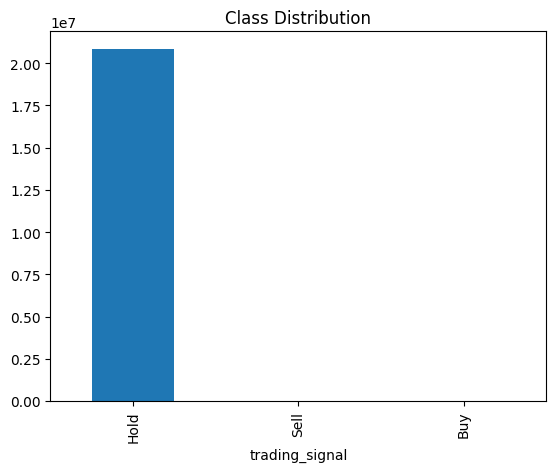

In [30]:
# Plot class distribution
df['trading_signal'].value_counts().plot(
kind='bar',
title='Class Distribution'
)

3- Prepare the Data for Machine Learning

Select the Features

In [31]:
# Calculate daily_range_pct

df['daily_range_pct'] = (
(df['high'] - df['low']) / df['open']
) * 100

In [32]:
# Select ML features and target
features = [
'daily_return',
'close_lag_1',
'ma_5',
'ma_20',
'volatility_20',
'daily_range_pct'
]

target = 'trading_signal'

Prepare the Target

In [33]:
# Encode the target variable
signal_mapping = {
'Buy': 0,
'Hold': 1,
'Sell': 2
}

df['trading_signal_encoded'] = df['trading_signal'].map(signal_mapping)

In [34]:
# Check target encoding
print(signal_mapping)

print(
df[
['trading_signal', 'trading_signal_encoded']
].drop_duplicates()
)

{'Buy': 0, 'Hold': 1, 'Sell': 2}
      trading_signal  trading_signal_encoded
0               Hold                       1
1439            Sell                       2
11880            Buy                       0


In [35]:
# Check target distribution
print(df['trading_signal_encoded'].value_counts())

trading_signal_encoded
1    20839526
2       11380
0        9428
Name: count, dtype: int64


Part 4 - Split the Data

Split the Data by Date

In [36]:
# Time-based train/test split

train = df[df['date'] < '2015-01-01']
#test = df[df['date'] >= '2015-01-01']

# Check the split
print("Training rows:", len(train))
#print("Test rows:", len(test))

print("\nTraining period:")
print(train['date'].min(), "to", train['date'].max())

# print("\nTest period:")
# print(test['date'].min(), "to", test['date'].max())

Training rows: 16293035

Training period:
1970-01-30 00:00:00 to 2014-12-31 00:00:00


In [37]:
print("Training target distribution:")
print(train[target].value_counts().sort_index())

print("\nTraining target proportions:")
print(train[target].value_counts(normalize=True).sort_index())

Training target distribution:
trading_signal
Buy         7052
Hold    16277380
Sell        8603
Name: count, dtype: int64

Training target proportions:
trading_signal
Buy     0.000433
Hold    0.999039
Sell    0.000528
Name: proportion, dtype: float64


Fit the scaler on the training data

In [38]:
# Create scaler
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [39]:
from sklearn.preprocessing import StandardScaler
import gc

scaler = StandardScaler()
batch_size = 100000

for start in range(0, len(train), batch_size):

    end = min(start + batch_size, len(train))

    batch = train[features].iloc[start:end].astype('float32')

    scaler.partial_fit(batch)

    print(f"Scaler fitting: {end:,} / {len(train):,}")

    del batch
    gc.collect()

print("Scaler fitted successfully.")

Scaler fitting: 100,000 / 16,293,035
Scaler fitting: 200,000 / 16,293,035
Scaler fitting: 300,000 / 16,293,035
Scaler fitting: 400,000 / 16,293,035
Scaler fitting: 500,000 / 16,293,035
Scaler fitting: 600,000 / 16,293,035
Scaler fitting: 700,000 / 16,293,035
Scaler fitting: 800,000 / 16,293,035
Scaler fitting: 900,000 / 16,293,035
Scaler fitting: 1,000,000 / 16,293,035
Scaler fitting: 1,100,000 / 16,293,035
Scaler fitting: 1,200,000 / 16,293,035
Scaler fitting: 1,300,000 / 16,293,035
Scaler fitting: 1,400,000 / 16,293,035
Scaler fitting: 1,500,000 / 16,293,035
Scaler fitting: 1,600,000 / 16,293,035
Scaler fitting: 1,700,000 / 16,293,035
Scaler fitting: 1,800,000 / 16,293,035
Scaler fitting: 1,900,000 / 16,293,035
Scaler fitting: 2,000,000 / 16,293,035
Scaler fitting: 2,100,000 / 16,293,035
Scaler fitting: 2,200,000 / 16,293,035
Scaler fitting: 2,300,000 / 16,293,035
Scaler fitting: 2,400,000 / 16,293,035
Scaler fitting: 2,500,000 / 16,293,035
Scaler fitting: 2,600,000 / 16,293,035
Scal

Select the training sample

In [40]:
# Select a representative sample from the training data
sample_size = 500000

train_sample = train.sample(
    n=sample_size,
    random_state=42
)

print("Training sample created.")
print("Sample size:", len(train_sample))

Training sample created.
Sample size: 500000


In [41]:
print("Sample target distribution:")
print(train_sample[target].value_counts().sort_index())

print("\nSample target proportions:")
print(train_sample[target].value_counts(normalize=True).sort_index())

Sample target distribution:
trading_signal
Buy        209
Hold    499557
Sell       234
Name: count, dtype: int64

Sample target proportions:
trading_signal
Buy     0.000418
Hold    0.999114
Sell    0.000468
Name: proportion, dtype: float64


Create X and y from the sample

In [42]:
# Create features and target for the training sample
X_train = train_sample[features]
y_train = train_sample['trading_signal_encoded']

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (500000, 6)
y_train shape: (500000,)


In [43]:
print("Training target distribution:")
print(train['trading_signal_encoded'].value_counts().sort_index())

print("\nTraining target proportions:")
print(train['trading_signal_encoded'].value_counts(normalize=True).sort_index())

Training target distribution:
trading_signal_encoded
0        7052
1    16277380
2        8603
Name: count, dtype: int64

Training target proportions:
trading_signal_encoded
0    0.000433
1    0.999039
2    0.000528
Name: proportion, dtype: float64


In [44]:
# delete the temporary objects

del train_sample
del train
gc.collect()

0

Apply the scaler

In [45]:
# Transform the sampled training features
X_train_scaled = scaler.transform(X_train).astype('float32')

print("Training features standardized.")
print("X_train_scaled shape:", X_train_scaled.shape)

Training features standardized.
X_train_scaled shape: (500000, 6)


Check the target distribution

In [46]:
print("\nTarget distribution in training sample:")
print(y_train.value_counts().sort_index())

print("\nTarget proportions:")
print(y_train.value_counts(normalize=True).sort_index())


Target distribution in training sample:
trading_signal_encoded
0       209
1    499557
2       234
Name: count, dtype: int64

Target proportions:
trading_signal_encoded
0    0.000418
1    0.999114
2    0.000468
Name: proportion, dtype: float64


In [47]:
'''
The dataset is highly imbalanced, with most observations belonging to one class. Therefore, I will use a more balanced training sample
to give the models enough observations from the minority classes to learn their patterns effectively.
The test dataset will remain unchanged so that the model can be evaluated on the real class distribution.
'''

'\nThe dataset is highly imbalanced, with most observations belonging to one class. Therefore, I will use a more balanced training sample\nto give the models enough observations from the minority classes to learn their patterns effectively.\nThe test dataset will remain unchanged so that the model can be evaluated on the real class distribution.\n'

Balance sample dataset

Get the row positions for each class in the training period

In [48]:
import numpy as np
import gc

# Training period: before 2015
train_mask = df['date'].to_numpy() < np.datetime64('2015-01-01')

# Use the encoded target
target_values = df['trading_signal_encoded'].to_numpy()

# Get row positions for each class
idx_0 = np.flatnonzero(train_mask & (target_values == 0))
idx_1 = np.flatnonzero(train_mask & (target_values == 1))
idx_2 = np.flatnonzero(train_mask & (target_values == 2))

print("Class 0:", len(idx_0))
print("Class 1:", len(idx_1))
print("Class 2:", len(idx_2))

del train_mask
del target_values
gc.collect()

Class 0: 7052
Class 1: 16277380
Class 2: 8603


0

In [49]:
# Select 100,000 observations from Class 1

rng = np.random.default_rng(42)

idx_1_sample = rng.choice(
    idx_1,
    size=100000,
    replace=False
)

print("Selected class 1:", len(idx_1_sample))

Selected class 1: 100000


In [50]:
# Combine the classes

sample_indices = np.concatenate([
    idx_0,
    idx_1_sample,
    idx_2
])

rng.shuffle(sample_indices)

print("Total sample size:", len(sample_indices))


Total sample size: 115655


In [51]:
# Create the training sample

train_sample = df.iloc[sample_indices]

print("Training sample created.")
print("Sample size:", len(train_sample))

print("\nClass distribution:")
print(
    train_sample['trading_signal_encoded']
    .value_counts()
    .sort_index()
)


Training sample created.
Sample size: 115655

Class distribution:
trading_signal_encoded
0      7052
1    100000
2      8603
Name: count, dtype: int64


In [52]:
# Create the training sample
X_train = train_sample[features]
y_train = train_sample[target]

Scale the training features

In [53]:
X_train_scaled = scaler.transform(X_train).astype('float32')

print("X_train_scaled shape:", X_train_scaled.shape)

X_train_scaled shape: (115655, 6)


Free memory

In [54]:
# import gc

del X_train
del train_sample
del idx_0
del idx_1
del idx_2
del idx_1_sample
del sample_indices

gc.collect()


print("X_train deleted.")

X_train deleted.


5. Build Machine Learning Models

Train the Models

In [55]:
# 1. Logistic Regression
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE
)

logistic_model.fit(X_train_scaled, y_train)

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


In [56]:
# 2. Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_model.fit(X_train_scaled, y_train)

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [57]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC(
    random_state=42,
    max_iter=2000
)

svm_model.fit(X_train_scaled, y_train)

print("Linear SVM trained successfully.")

Linear SVM trained successfully.


In [58]:
# # 3. Support Vector Machine
# svm_model = SVC(
#     kernel='rbf',
#     random_state=RANDOM_STATE
# )

# svm_model.fit(X_train_scaled, y_train)

# print("SVM trained successfully.")

#6. Evaluate the Models

Import the Evaluation Tools

In [59]:
import numpy as np
import pandas as pd
import gc

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix
)

Create the Test Dataset

In [60]:
# Test data: January 1, 2015 onward
test = df[df['date'] >= '2015-01-01']

In [61]:
# Convert test trading signals to numeric labels
test_target = test['trading_signal'].map({
    'Buy': 0,
    'Hold': 1,
    'Sell': 2
})

print(test_target.value_counts().sort_index())
print("\nMissing values:", test_target.isna().sum())

trading_signal
0       2376
1    4562146
2       2777
Name: count, dtype: int64

Missing values: 0


In [62]:
test_target = test['trading_signal']

print(test_target.unique())

['Hold' 'Sell' 'Buy']


Define the Three Models

In [63]:
models = {
    "Logistic Regression": logistic_model,
    "Random Forest": rf_model,
    "SVM": svm_model
}

Evaluate the Three Models

In [64]:
results = {}
confusion_matrices = {}

batch_size = 100000

for model_name, model in models.items():

    print("\n" + "=" * 50)
    print(f"Evaluating: {model_name}")
    print("=" * 50)

    y_true_all = []
    y_pred_all = []

    for start in range(0, len(test), batch_size):

        end = min(start + batch_size, len(test))

        # Select test batch
        X_batch = test[features].iloc[start:end].astype('float32')
        y_batch = test_target.iloc[start:end].to_numpy()

        # Scale using the training scaler
        X_batch_scaled = scaler.transform(X_batch).astype('float32')

        # Predictions
        y_pred_batch = model.predict(X_batch_scaled)

        # Store actual and predicted labels
        y_true_all.append(y_batch)
        y_pred_all.append(y_pred_batch)

        # Free memory
        del X_batch
        del X_batch_scaled
        del y_batch
        del y_pred_batch

        gc.collect()

        print(f"Processed: {end:,} / {len(test):,}")

    # Combine batches
    y_true = np.concatenate(y_true_all)
    y_pred = np.concatenate(y_pred_all)

    # Calculate metrics
    accuracy = accuracy_score(y_true, y_pred)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=['Buy', 'Hold', 'Sell'],
        zero_division=0
    )

    results[model_name] = {
        "Accuracy": accuracy,
        "Precision": precision.mean(),
        "Recall": recall.mean(),
        "F1-score": f1.mean()
    }

    # Confusion matrix
    confusion_matrices[model_name] = confusion_matrix(
        y_true,
        y_pred,
        labels=['Buy', 'Hold', 'Sell']
    )

    print(f"{model_name} evaluation completed.")

    # Free memory
    del y_true
    del y_pred
    del y_true_all
    del y_pred_all

    gc.collect()


Evaluating: Logistic Regression
Processed: 100,000 / 4,567,299
Processed: 200,000 / 4,567,299
Processed: 300,000 / 4,567,299
Processed: 400,000 / 4,567,299
Processed: 500,000 / 4,567,299
Processed: 600,000 / 4,567,299
Processed: 700,000 / 4,567,299
Processed: 800,000 / 4,567,299
Processed: 900,000 / 4,567,299
Processed: 1,000,000 / 4,567,299
Processed: 1,100,000 / 4,567,299
Processed: 1,200,000 / 4,567,299
Processed: 1,300,000 / 4,567,299
Processed: 1,400,000 / 4,567,299
Processed: 1,500,000 / 4,567,299
Processed: 1,600,000 / 4,567,299
Processed: 1,700,000 / 4,567,299
Processed: 1,800,000 / 4,567,299
Processed: 1,900,000 / 4,567,299
Processed: 2,000,000 / 4,567,299
Processed: 2,100,000 / 4,567,299
Processed: 2,200,000 / 4,567,299
Processed: 2,300,000 / 4,567,299
Processed: 2,400,000 / 4,567,299
Processed: 2,500,000 / 4,567,299
Processed: 2,600,000 / 4,567,299
Processed: 2,700,000 / 4,567,299
Processed: 2,800,000 / 4,567,299
Processed: 2,900,000 / 4,567,299
Processed: 3,000,000 / 4,567

Compare the Three Models

In [65]:
results_df = pd.DataFrame(results).T

print("\nModel Comparison")
display(results_df.round(4))


Model Comparison


,Accuracy,Precision,Recall,F1-score
Logistic Regression,0.9988,0.3475,0.3338,0.3341
Random Forest,0.9932,0.3406,0.3775,0.3451
SVM,0.9988,0.3465,0.3337,0.3339


Display the Confusion Matrices

In [66]:
for model_name, cm in confusion_matrices.items():

    print("\n" + "=" * 50)
    print(f"Confusion Matrix: {model_name}")
    print("=" * 50)

    cm_df = pd.DataFrame(
        cm,
        index=['Actual Buy', 'Actual Hold', 'Actual Sell'],
        columns=['Predicted Buy', 'Predicted Hold', 'Predicted Sell']
    )

    display(cm_df)


Confusion Matrix: Logistic Regression


,Predicted Buy,Predicted Hold,Predicted Sell
Actual Buy,2,2374,0
Actual Hold,51,4561750,345
Actual Sell,0,2775,2



Confusion Matrix: Random Forest


,Predicted Buy,Predicted Hold,Predicted Sell
Actual Buy,283,2091,2
Actual Hold,15520,4535737,10889
Actual Sell,12,2712,53



Confusion Matrix: SVM


,Predicted Buy,Predicted Hold,Predicted Sell
Actual Buy,1,2375,0
Actual Hold,35,4561958,153
Actual Sell,0,2775,2


In [67]:
del test
gc.collect()

print("Test data deleted from memory.")

Test data deleted from memory.


Logistic Regression metrics

In [68]:
cm = confusion_matrices['Logistic Regression']

cm_df = pd.DataFrame(
    cm,
    index=['Actual Buy', 'Actual Hold', 'Actual Sell'],
    columns=['Predicted Buy', 'Predicted Hold', 'Predicted Sell']
)

print("Confusion Matrix: Logistic Regression")
display(cm_df)

Confusion Matrix: Logistic Regression


,Predicted Buy,Predicted Hold,Predicted Sell
Actual Buy,2,2374,0
Actual Hold,51,4561750,345
Actual Sell,0,2775,2


model metrics comparison

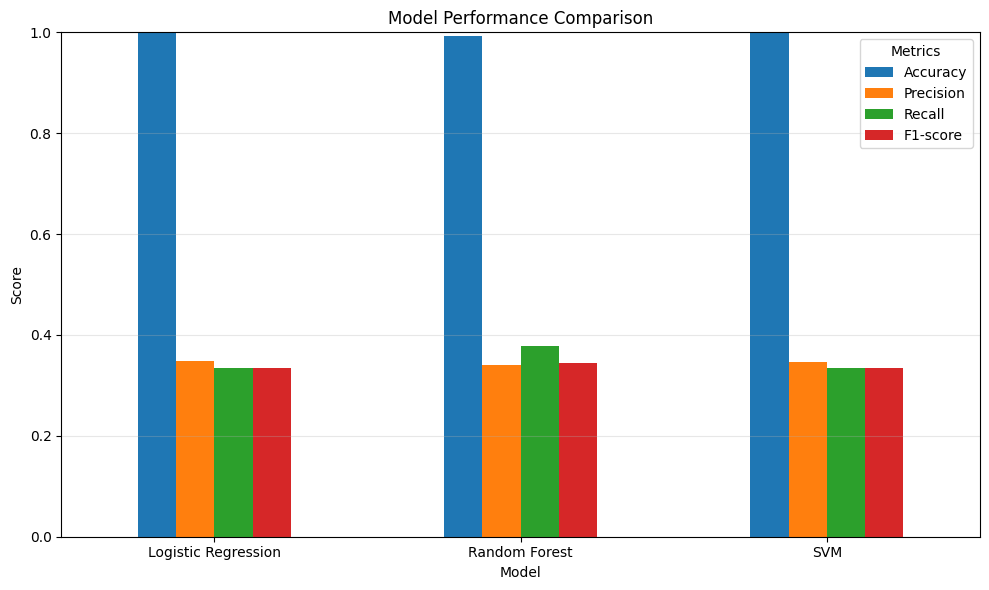

In [69]:
import matplotlib.pyplot as plt

# Create a bar chart from the results table
results_df.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Model Performance Comparison')
plt.xlabel('Model')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title='Metrics')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Confusion Matrix Graphs

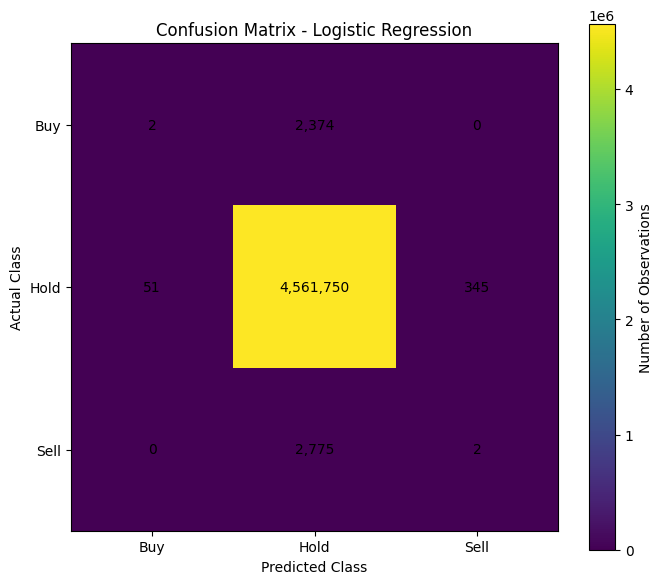

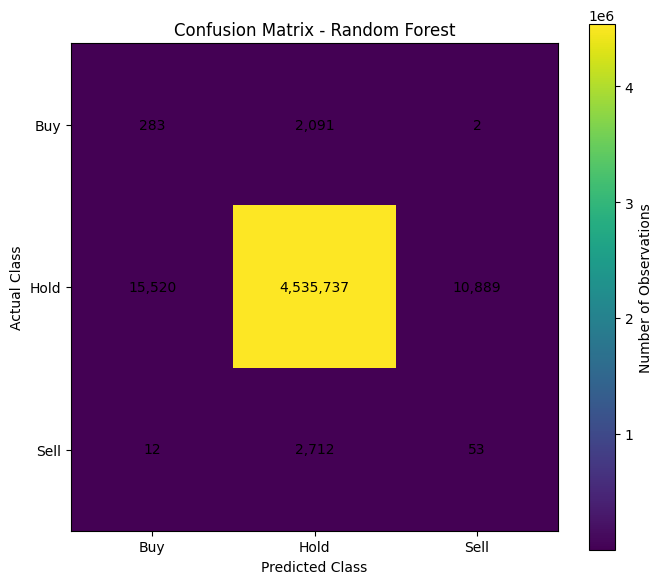

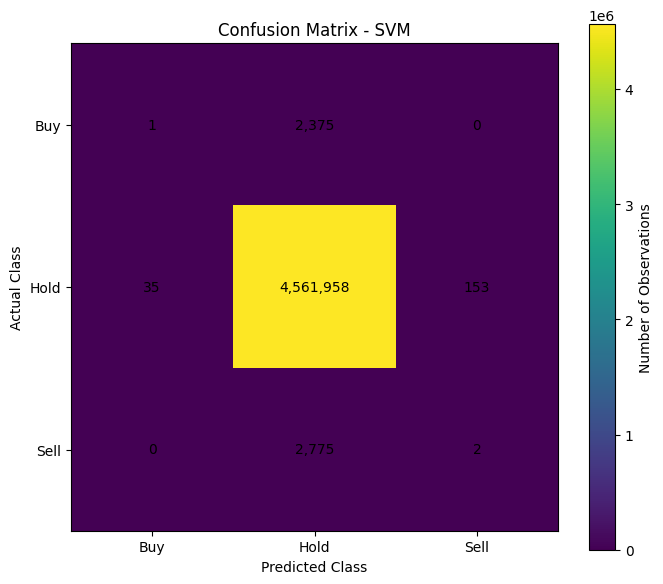

In [70]:
import matplotlib.pyplot as plt
import numpy as np

class_names = ['Buy', 'Hold', 'Sell']

for model_name, cm in confusion_matrices.items():

    plt.figure(figsize=(7, 6))

    plt.imshow(cm)

    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted Class')
    plt.ylabel('Actual Class')

    plt.xticks(np.arange(3), class_names)
    plt.yticks(np.arange(3), class_names)

    # Add numbers inside each cell
    for i in range(3):
        for j in range(3):
            plt.text(
                j, i,
                f'{cm[i, j]:,}',
                ha='center',
                va='center'
            )

    plt.colorbar(label='Number of Observations')
    plt.tight_layout()
    plt.show()

In [71]:
'''

Random Forest performed better in identifying the minority classes, Buy and Sell.
Therefore, it is the model selected for improvement.
'''

'\n\nRandom Forest performed better in identifying the minority classes, Buy and Sell.\nTherefore, it is the model selected for improvement.\n'

# 7. Improve One Model

In [72]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

In [73]:
# Create a validation set from the training data

X_train_part, X_valid, y_train_part, y_valid = train_test_split(
    X_train_scaled,
    y_train,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_train
)

print("Training set shape:", X_train_part.shape)
print("Validation set shape:", X_valid.shape)

Training set shape: (92524, 6)
Validation set shape: (23131, 6)


Test different max_depth values

In [74]:
# Test different max_depth values

max_depth_values = [10, 20, 30]

validation_results = []

for depth in max_depth_values:

    rf_temp = RandomForestClassifier(
        n_estimators=100,
        max_depth=depth,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    rf_temp.fit(X_train_part, y_train_part)

    y_valid_pred = rf_temp.predict(X_valid)

    valid_accuracy = accuracy_score(y_valid, y_valid_pred)

    valid_macro_f1 = f1_score(
        y_valid,
        y_valid_pred,
        average="macro"
    )

    validation_results.append({
        "max_depth": depth,
        "Validation Accuracy": valid_accuracy,
        "Validation Macro F1": valid_macro_f1
    })

validation_results_df = pd.DataFrame(validation_results)

print("\nValidation Results:")
display(validation_results_df)


Validation Results:


,max_depth,Validation Accuracy,Validation Macro F1
0,10,0.865981,0.335586
1,20,0.867105,0.375492
2,30,0.867753,0.390372


Select the best max_depth

In [75]:
best_depth = validation_results_df.loc[
    validation_results_df["Validation Macro F1"].idxmax(),
    "max_depth"
]

print("\nBest max_depth:", best_depth)


Best max_depth: 30


 Train the improved Random Forest

In [76]:
rf_improved = RandomForestClassifier(
    n_estimators=100,
    max_depth=int(best_depth),
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_improved.fit(X_train_scaled, y_train)

print("Improved Random Forest trained successfully.")

Improved Random Forest trained successfully.


 Evaluate the improved model

In [77]:
# Extract the test dataset
test = df[df['date'] >= '2015-01-01']

# Store predictions from all batches
y_true_all = []
y_pred_all = []

# Use the same batch size as the original evaluation
batch_size = 100000

for start in range(0, len(test), batch_size):

    end = min(start + batch_size, len(test))

    # Select a test batch
    X_batch = test[features].iloc[start:end].astype('float32')
    y_batch = test_target.iloc[start:end].to_numpy()

    # Scale using the scaler fitted on the training data
    X_batch_scaled = scaler.transform(X_batch).astype('float32')

    # Predictions from the improved Random Forest
    y_pred_batch = rf_improved.predict(X_batch_scaled)

    # Store actual and predicted labels
    y_true_all.append(y_batch)
    y_pred_all.append(y_pred_batch)

    # Free memory
    del X_batch
    del X_batch_scaled
    del y_batch
    del y_pred_batch

    gc.collect()

    print(f"Processed: {end:,} / {len(test):,}")

Processed: 100,000 / 4,567,299
Processed: 200,000 / 4,567,299
Processed: 300,000 / 4,567,299
Processed: 400,000 / 4,567,299
Processed: 500,000 / 4,567,299
Processed: 600,000 / 4,567,299
Processed: 700,000 / 4,567,299
Processed: 800,000 / 4,567,299
Processed: 900,000 / 4,567,299
Processed: 1,000,000 / 4,567,299
Processed: 1,100,000 / 4,567,299
Processed: 1,200,000 / 4,567,299
Processed: 1,300,000 / 4,567,299
Processed: 1,400,000 / 4,567,299
Processed: 1,500,000 / 4,567,299
Processed: 1,600,000 / 4,567,299
Processed: 1,700,000 / 4,567,299
Processed: 1,800,000 / 4,567,299
Processed: 1,900,000 / 4,567,299
Processed: 2,000,000 / 4,567,299
Processed: 2,100,000 / 4,567,299
Processed: 2,200,000 / 4,567,299
Processed: 2,300,000 / 4,567,299
Processed: 2,400,000 / 4,567,299
Processed: 2,500,000 / 4,567,299
Processed: 2,600,000 / 4,567,299
Processed: 2,700,000 / 4,567,299
Processed: 2,800,000 / 4,567,299
Processed: 2,900,000 / 4,567,299
Processed: 3,000,000 / 4,567,299
Processed: 3,100,000 / 4,567

 Combine all batches

In [78]:
#  Combine all batches

y_true_improved = np.concatenate(y_true_all)
y_pred_improved = np.concatenate(y_pred_all)

In [79]:
# Calculate performance metrics

accuracy_improved = accuracy_score(
    y_true_improved,
    y_pred_improved
)

precision, recall, f1, _ = precision_recall_fscore_support(
    y_true_improved,
    y_pred_improved,
    labels=['Buy', 'Hold', 'Sell'],
    zero_division=0
)


print("Improved Random Forest - Test Results")

print(f"Accuracy: {accuracy_improved:.4f}")
print(f"Macro Precision: {precision.mean():.4f}")
print(f"Macro Recall: {recall.mean():.4f}")
print(f"Macro F1-score: {f1.mean():.4f}")


Improved Random Forest - Test Results
Accuracy: 0.9939
Macro Precision: 0.3411
Macro Recall: 0.3771
Macro F1-score: 0.3459


In [80]:
#  Classification report
print("\nClassification Report:")

print(
    classification_report(
        y_true_improved,
        y_pred_improved,
        labels=['Buy', 'Hold', 'Sell'],
        zero_division=0
    )
)



Classification Report:
              precision    recall  f1-score   support

         Buy       0.02      0.12      0.03      2376
        Hold       1.00      0.99      1.00   4562146
        Sell       0.01      0.02      0.01      2777

    accuracy                           0.99   4567299
   macro avg       0.34      0.38      0.35   4567299
weighted avg       1.00      0.99      1.00   4567299



In [81]:
# Confusion Matrix


print("Confusion Matrix: Improved Random Forest")


cm_improved = confusion_matrix(
    y_true_improved,
    y_pred_improved,
    labels=['Buy', 'Hold', 'Sell']
)

print(cm_improved)

Confusion Matrix: Improved Random Forest
[[    288    2086       2]
 [  14750 4539190    8206]
 [     12    2723      42]]


In [82]:
# Free memory

del y_true_improved
del y_pred_improved
del y_true_all
del y_pred_all
del test
del cm_improved

gc.collect()

0